# Phase 2: Hierarchical Environmental-Taxonomic Modeling

**Goal**: Use multivariate models to identify which **combinations** of environmental variables predict microbial taxonomic composition across 4,789 spatial clusters.

## Rationale for Aggressive Approach

Based on Phase 1 findings:
- **Weak univariate signals**: Pseudomonadota prediction AUC ~0.51 (essentially random)
- **High multicollinearity**: Mean |r| = 0.197 across 155 environmental variables
- **Correlation clustering**: 72 distinct clusters from 155 variables
- **Cross-domain confounding**: 396 correlations |r| > 0.5 across environmental domains
- **Complementary embeddings**: Mean |r| = 0.16 between embeddings and explicit env variables

**Conclusion**: Single-variable associations are obscured by environmental complexity. Multivariate models are needed to reveal taxonomic-environmental relationships.

## Analysis Strategy

1. **Quick Dimensionality Reduction** (Section 2): Domain-specific PCA to extract major gradients
2. **Hierarchical Modeling** (Section 3): CatBoost models at multiple taxonomic levels
3. **Conditional Importance** (Section 4): What matters given confounds?
4. **Divergence Analysis** (Section 5): Where do child taxa diverge in their environmental associations?
5. **Interpretation** (Section 6): Biological meaning of environmental gradients

---

## 1. Setup and Data Loading

In [1]:
import sys
import warnings
from pathlib import Path
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
from sklearn.inspection import permutation_importance

import catboost as cb
from catboost import CatBoostClassifier, Pool

warnings.filterwarnings('ignore')

# Set repository root (for config loading)
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'analysis').exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print(f"Repository root: {REPO_ROOT}")
print(f"CatBoost version: {cb.__version__}")

Repository root: /usr/aparkin/enigma/analyses/2025-08-23-Soil Adaptor from GPT5/env-agents
CatBoost version: 1.2.8


### 1.1. Load Configuration

In [2]:
import yaml

CONFIG_PATH = REPO_ROOT / 'analysis' / 'config.yaml'
with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)

# Extract relevant parameters
TAXONOMIC_LEVELS = config['taxonomy']['levels']
MIN_PREVALENCE = config['taxonomy']['min_prevalence']
OUTPUT_DIR = REPO_ROOT / config['paths']['results_dir']
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Modeling parameters
TEST_SIZE = config['modeling']['test_size']
CV_FOLDS = config['modeling']['cv_folds']
RANDOM_STATE = config['modeling']['random_state']
CATBOOST_PARAMS = config['modeling']['catboost']

# Divergence analysis parameters
DIV_MIN_PREVALENCE = config['divergence']['min_prevalence']
DIV_THRESHOLD = config['divergence']['divergence_threshold']
DIV_CORR_THRESHOLD = config['divergence']['correlation_threshold']
DIV_N_PERM = config['divergence']['n_permutations']
DIV_TOP_VARS = config['divergence']['top_discriminating_vars']

print(f"Configuration loaded from: {CONFIG_PATH}")
print(f"Taxonomic levels: {TAXONOMIC_LEVELS}")
print(f"Min prevalence for taxa: {MIN_PREVALENCE:.1%}")
print(f"Output directory: {OUTPUT_DIR}")

Configuration loaded from: /usr/aparkin/enigma/analyses/2025-08-23-Soil Adaptor from GPT5/env-agents/analysis/config.yaml
Taxonomic levels: ['phylum', 'class', 'order', 'family', 'genus']
Min prevalence for taxa: 1.0%
Output directory: /usr/aparkin/enigma/analyses/2025-08-23-Soil Adaptor from GPT5/env-agents/analysis/results


### 1.2. Load Prepared Data

Load the pivoted environmental data and taxonomy from Phase 1.

In [3]:
# Load from Phase 1 outputs
DATA_DIR = REPO_ROOT / config['paths']['output_dir'] / 'phase1_outputs'

df_wide = pd.read_parquet(DATA_DIR / 'df_wide.parquet')
df_taxonomy = pd.read_parquet(DATA_DIR / 'df_taxonomy.parquet')

# Load cluster mapping
clusters = pd.read_csv(REPO_ROOT / 'notebooks' / 'clusters_optimized.csv')

print(f"Data loaded from: {DATA_DIR}")
print(f"  df_wide (clusters × env vars): {df_wide.shape}")
print(f"  df_taxonomy (genomes): {df_taxonomy.shape}")
print(f"  clusters mapping: {clusters.shape}")

# Create combined dataset: genomes with both environmental data and taxonomy
# Each genome inherits environmental data from its cluster
print("\nCreating combined dataset (genomes with env + taxonomy)...")

genome_cluster_map = []
for _, row in clusters.iterrows():
    cluster_id = row['cluster_id']
    # Parse points list (stored as string representation of list)
    points = eval(row['points']) if isinstance(row['points'], str) else row['points']
    for genome_idx in points:
        genome_cluster_map.append({'genome_idx': genome_idx, 'cluster_id': cluster_id})

df_genome_cluster = pd.DataFrame(genome_cluster_map)

# Add cluster environmental data to each genome
df_genome_cluster = df_genome_cluster.set_index('cluster_id').join(df_wide, how='left')

# Add taxonomy for each genome
df_combined = df_genome_cluster.reset_index()
df_combined = df_combined.merge(
    df_taxonomy.reset_index()[['index', 'genome_id', 'domain', 'phylum', 'class', 'order', 'family', 'genus', 'species']],
    left_on='genome_idx',
    right_on='index',
    how='left'
)

print(f"\nCombined dataset: {df_combined.shape}")
print(f"  Genomes with env + taxonomy: {len(df_combined):,}")

# Identify variable types
env_cols = [col for col in df_wide.columns if '__' in col]
embedding_cols = [col for col in env_cols if col.startswith('GOOGLE_EMBEDDINGS__')]
explicit_env_cols = [col for col in env_cols if col not in embedding_cols]

# Remove QA flags from explicit environmental variables
explicit_env_cols = [col for col in explicit_env_cols 
                     if not any(x in col.lower() for x in ['qa', 'summaryqa', 'detailqa', 'pixel'])]

print(f"\nVariable breakdown:")
print(f"  Explicit environmental: {len(explicit_env_cols)}")
print(f"  Google embeddings: {len(embedding_cols)}")
print(f"  Total: {len(explicit_env_cols) + len(embedding_cols)}")

Data loaded from: /usr/aparkin/enigma/analyses/2025-08-23-Soil Adaptor from GPT5/env-agents/analysis/data/phase1_outputs
  df_wide (clusters × env vars): (4789, 315)
  df_taxonomy (genomes): (83287, 26)
  clusters mapping: (4789, 6)

Creating combined dataset (genomes with env + taxonomy)...

Combined dataset: (10198, 326)
  Genomes with env + taxonomy: 10,198

Variable breakdown:
  Explicit environmental: 247
  Google embeddings: 64
  Total: 311


### 1.3. Select Complete Cases

Use clusters with ≥50% environmental data completeness for modeling.

In [4]:
# Calculate completeness for each cluster
all_env_cols = explicit_env_cols + embedding_cols
completeness = df_wide[all_env_cols].notna().sum(axis=1) / len(all_env_cols)

# Filter to reasonably complete cases
completeness_threshold = config['missing']['cluster_completeness_threshold']
complete_clusters = completeness[completeness >= completeness_threshold].index.tolist()

print(f"Completeness threshold: {completeness_threshold:.0%}")
print(f"Clusters meeting threshold: {len(complete_clusters):,} / {len(df_wide):,} ({len(complete_clusters)/len(df_wide):.1%})")

# Filter combined dataset to genomes in complete clusters
df_model = df_combined[df_combined['cluster_id'].isin(complete_clusters)].copy()

print(f"\nModeling dataset: {df_model.shape}")
print(f"Genomes in complete clusters: {len(df_model):,}")
print(f"Unique clusters: {df_model['cluster_id'].nunique():,}")

Completeness threshold: 50%
Clusters meeting threshold: 4,789 / 4,789 (100.0%)

Modeling dataset: (10198, 326)
Genomes in complete clusters: 10,198
Unique clusters: 4,789


### 1.4. Define Environmental Domains

Group variables by domain for PCA.

In [5]:
# Define domain mappings from config
domain_map = {
    'climate': config['phase3']['pca_by_domain']['climate'],
    'soil': config['phase3']['pca_by_domain']['soil'],
    'vegetation': config['phase3']['pca_by_domain']['vegetation'],
    'embeddings': config['phase3']['pca_by_domain']['embeddings']
}

# Map each variable to its domain
domain_vars = {}
for domain, service_prefixes in domain_map.items():
    domain_cols = [col for col in explicit_env_cols 
                   if any(col.startswith(prefix) for prefix in service_prefixes)]
    if domain == 'embeddings':
        domain_cols = embedding_cols
    domain_vars[domain] = domain_cols

# Add topography (SRTM)
domain_vars['topography'] = [col for col in explicit_env_cols if col.startswith('SRTM')]

print("Environmental domains:")
for domain, vars_list in domain_vars.items():
    print(f"  {domain}: {len(vars_list)} variables")

Environmental domains:
  climate: 39 variables
  soil: 18 variables
  vegetation: 33 variables
  embeddings: 64 variables
  topography: 1 variables


---
## 2. Domain-Specific Dimensionality Reduction

Apply PCA separately to each environmental domain to extract major gradients. This reduces 155 variables to ~20-30 principal components representing core environmental axes.

### 2.1. PCA by Domain

In [6]:
# Target variance explained from config
target_variance = config['phase3']['pca_variance_explained']

# Work at CLUSTER level for PCA (each cluster has same environmental data)
df_clusters_complete = df_wide.loc[complete_clusters].copy()

# Store PCA results
pca_models = {}
pca_components = {}
pca_explained_var = {}

print(f"Applying PCA to each domain (target: {target_variance:.0%} variance explained)\n")

for domain, vars_list in domain_vars.items():
    if len(vars_list) == 0:
        print(f"{domain}: Skipped (no variables)")
        continue
    
    # Extract domain data
    X_domain = df_clusters_complete[vars_list].copy()
    
    # Handle missing values (fill with median)
    X_domain = X_domain.fillna(X_domain.median())
    
    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_domain)
    
    # Fit PCA
    pca = PCA(n_components=target_variance, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_scaled)
    
    # Store results
    pca_models[domain] = (pca, scaler)
    n_components = X_pca.shape[1]
    
    # Create component names
    component_names = [f"{domain}_PC{i+1}" for i in range(n_components)]
    pca_components[domain] = pd.DataFrame(
        X_pca,
        index=df_clusters_complete.index,  # cluster_id index
        columns=component_names
    )
    
    pca_explained_var[domain] = pca.explained_variance_ratio_
    
    print(f"{domain}:")
    print(f"  {len(vars_list)} variables → {n_components} PCs")
    print(f"  Total variance explained: {pca.explained_variance_ratio_.sum():.1%}")
    print(f"  Top 3 PCs: {pca.explained_variance_ratio_[:3].sum():.1%}\n")

Applying PCA to each domain (target: 90% variance explained)

climate:
  39 variables → 11 PCs
  Total variance explained: 91.3%
  Top 3 PCs: 65.4%

soil:
  18 variables → 3 PCs
  Total variance explained: 95.2%
  Top 3 PCs: 95.2%

vegetation:
  33 variables → 9 PCs
  Total variance explained: 92.5%
  Top 3 PCs: 53.3%

embeddings:
  64 variables → 31 PCs
  Total variance explained: 90.1%
  Top 3 PCs: 29.5%

topography:
  1 variables → 1 PCs
  Total variance explained: 100.0%
  Top 3 PCs: 100.0%



### 2.2. Visualize Variance Explained

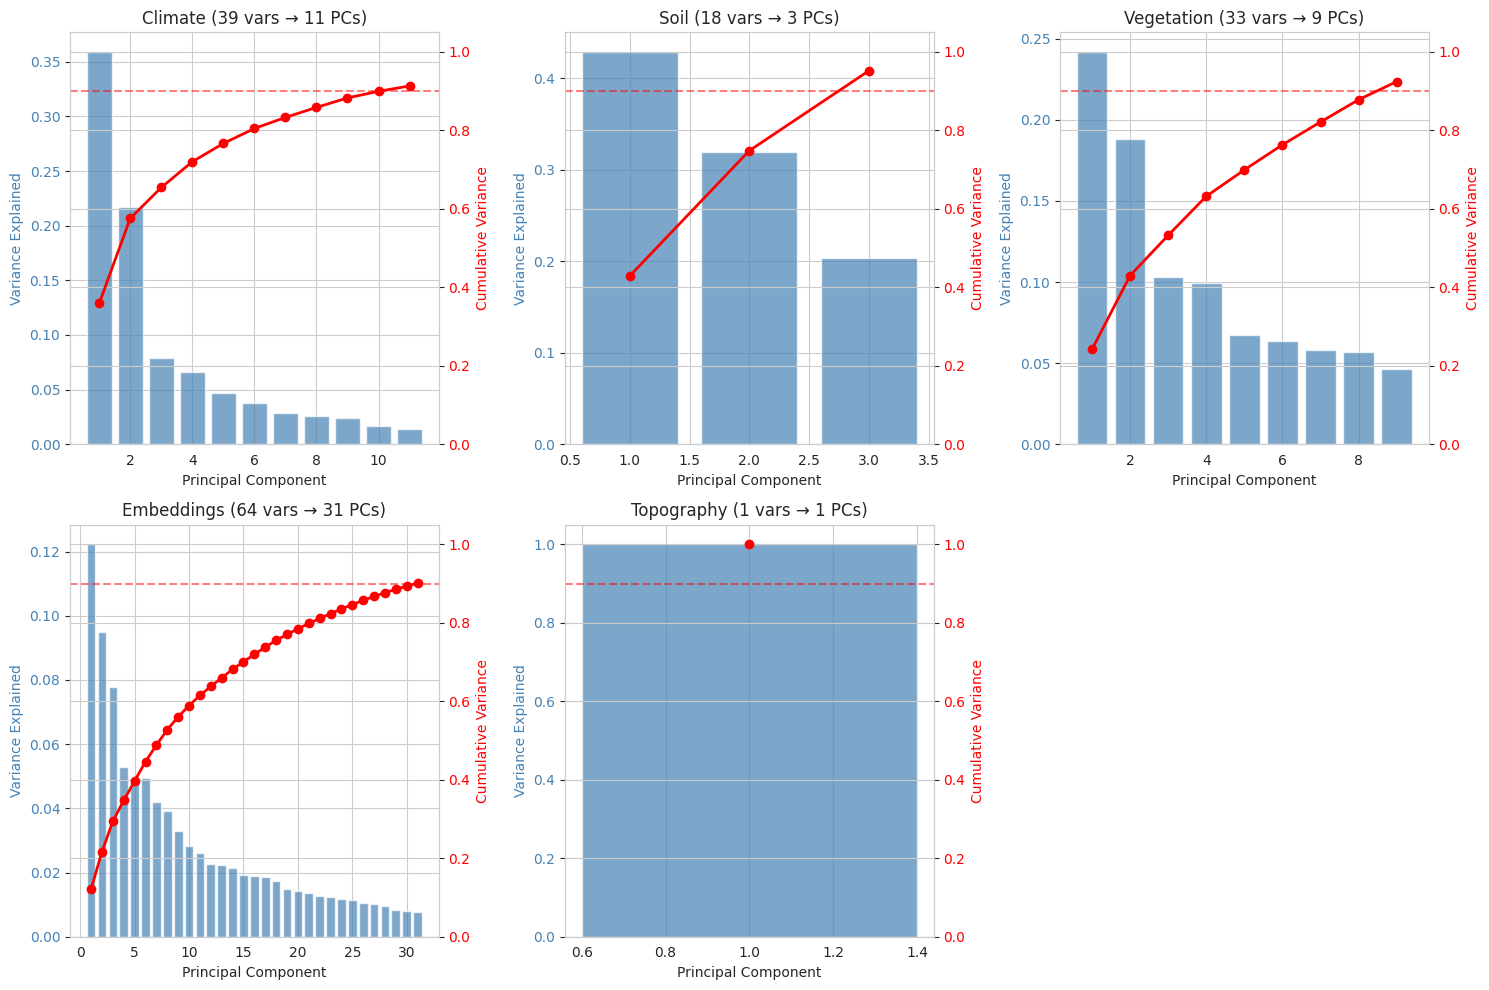

Saved: pca_variance_explained_by_domain.pdf


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (domain, var_explained) in enumerate(pca_explained_var.items()):
    ax = axes[i]
    
    # Plot variance explained per component
    ax.bar(range(1, len(var_explained)+1), var_explained, alpha=0.7, color='steelblue')
    
    # Plot cumulative variance
    ax2 = ax.twinx()
    cumsum = np.cumsum(var_explained)
    ax2.plot(range(1, len(var_explained)+1), cumsum, 'ro-', linewidth=2)
    ax2.axhline(y=target_variance, color='red', linestyle='--', alpha=0.5)
    ax2.set_ylim([0, 1.05])
    ax2.set_ylabel('Cumulative Variance', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    
    ax.set_xlabel('Principal Component')
    ax.set_ylabel('Variance Explained', color='steelblue')
    ax.set_title(f"{domain.capitalize()} ({len(domain_vars[domain])} vars → {len(var_explained)} PCs)")
    ax.tick_params(axis='y', labelcolor='steelblue')

# Remove extra subplots if needed
for j in range(len(pca_explained_var), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pca_variance_explained_by_domain.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: pca_variance_explained_by_domain.pdf")

### 2.3. Create Combined Feature Matrix

Combine all PCA components into a single feature matrix for modeling.

In [8]:
# Concatenate all PCA components (at cluster level)
df_pca_all = pd.concat(list(pca_components.values()), axis=1)

# Join PCA features to genome-level data via cluster_id
df_model_pca = df_model.set_index('cluster_id').join(df_pca_all, how='left').reset_index()

print(f"Combined feature matrix:")
print(f"  Shape: {df_model_pca.shape}")
print(f"  Genomes: {len(df_model_pca):,}")
print(f"  PCA features: {df_pca_all.shape[1]}")
print(f"\nPCA features by domain:")
for domain, df_comp in pca_components.items():
    print(f"  {domain}: {df_comp.shape[1]} PCs")

# Get list of all PCA feature names
pca_feature_names = df_pca_all.columns.tolist()
print(f"\nTotal PCA features: {len(pca_feature_names)}")

Combined feature matrix:
  Shape: (10198, 381)
  Genomes: 10,198
  PCA features: 55

PCA features by domain:
  climate: 11 PCs
  soil: 3 PCs
  vegetation: 9 PCs
  embeddings: 31 PCs
  topography: 1 PCs

Total PCA features: 55


---
## 3. Hierarchical Taxonomic Modeling

Build CatBoost classifiers to predict taxonomic presence/absence from environmental gradients. Test at multiple taxonomic levels to understand scale-dependent patterns.

### 3.1. Identify Major Taxa at Each Level

In [9]:
# Identify prevalent taxa at each taxonomic level
major_taxa = {}

for tax_level in TAXONOMIC_LEVELS:
    if tax_level not in df_model_pca.columns:
        continue
    
    # Count occurrences
    taxa_counts = df_model_pca[tax_level].value_counts()
    
    # Filter by prevalence
    min_count = int(len(df_model_pca) * MIN_PREVALENCE)
    prevalent = taxa_counts[taxa_counts >= min_count].index.tolist()
    
    major_taxa[tax_level] = prevalent
    
    print(f"{tax_level.capitalize()}: {len(prevalent)} taxa with ≥{MIN_PREVALENCE:.1%} prevalence")

print(f"\nTotal taxa for modeling: {sum(len(v) for v in major_taxa.values())}")

Phylum: 9 taxa with ≥1.0% prevalence
Class: 10 taxa with ≥1.0% prevalence
Order: 17 taxa with ≥1.0% prevalence
Family: 16 taxa with ≥1.0% prevalence
Genus: 15 taxa with ≥1.0% prevalence

Total taxa for modeling: 67


### 3.2. Build CatBoost Models for Major Phyla

Start with phylum-level models as proof of concept.

In [10]:
# Store model results
model_results = []
trained_models = {}

print(f"Training CatBoost models for all taxonomic levels...\n")
print("Note: Using fewer iterations and CV folds for speed. Increase for production runs.\n")

# Loop over all taxonomic levels
for tax_level in TAXONOMIC_LEVELS:
    if tax_level not in major_taxa:
        print(f"Skipping {tax_level} (no taxa identified)")
        continue
    
    target_taxa = major_taxa[tax_level]
    print(f"{'='*60}")
    print(f"{tax_level.upper()}: Training models for {len(target_taxa)} taxa")
    print(f"{'='*60}\n")
    
    # Limit number of models per level for speed
    max_models_per_level = 10
    
    for i, taxon in enumerate(target_taxa[:max_models_per_level], 1):
        print(f"  [{i}/{min(max_models_per_level, len(target_taxa))}] {taxon.split('__')[-1][:40]}...", end=' ', flush=True)
        
        # Create binary target
        y = (df_model_pca[tax_level] == taxon).astype(int)
        X = df_model_pca[pca_feature_names].fillna(0)  # Fill any remaining NaNs with 0
        
        # Check class balance
        prevalence = y.mean()
        if prevalence < 0.05 or prevalence > 0.95:
            print(f"skipped (imbalance: {prevalence:.1%})")
            continue
        
        # Train/test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
        )
        
        # Create CatBoost classifier with reduced iterations for speed
        model = CatBoostClassifier(
            iterations=500,  # Reduced from 1000 for speed
            learning_rate=CATBOOST_PARAMS['learning_rate'],
            depth=CATBOOST_PARAMS['depth'],
            l2_leaf_reg=CATBOOST_PARAMS['l2_leaf_reg'],
            loss_function=CATBOOST_PARAMS['loss_function'],
            eval_metric=CATBOOST_PARAMS['eval_metric'],
            early_stopping_rounds=CATBOOST_PARAMS['early_stopping_rounds'],
            random_state=RANDOM_STATE,
            verbose=False
        )
        
        # Train
        model.fit(
            X_train, y_train,
            eval_set=(X_test, y_test),
            verbose=False
        )
        
        # Evaluate
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        test_auc = roc_auc_score(y_test, y_pred_proba)
        
        # Skip CV for genus level (too many models, too slow)
        if tax_level == 'genus':
            cv_auc_mean = test_auc  # Use test AUC as estimate
            cv_auc_std = 0.0
        else:
            # Cross-validation with only 3 folds for speed
            cv_scores = cross_val_score(
                model, X, y, cv=3, scoring='roc_auc', n_jobs=-1
            )
            cv_auc_mean = cv_scores.mean()
            cv_auc_std = cv_scores.std()
        
        # Store results
        model_results.append({
            'tax_level': tax_level,
            'taxon': taxon,
            'prevalence': prevalence,
            'n_train': len(y_train),
            'n_test': len(y_test),
            'test_auc': test_auc,
            'cv_auc_mean': cv_auc_mean,
            'cv_auc_std': cv_auc_std,
            'n_features': X.shape[1],
            'best_iteration': model.best_iteration_
        })
        
        # Store model with full key
        model_key = f"{tax_level}__{taxon}"
        trained_models[model_key] = model
        
        print(f"prev={prevalence:.1%}, test_auc={test_auc:.3f}, cv_auc={cv_auc_mean:.3f}±{cv_auc_std:.3f}")
    
    print()

# Create results dataframe
df_results = pd.DataFrame(model_results)
df_results = df_results.sort_values('test_auc', ascending=False)

print(f"{'='*60}")
print(f"COMPLETED: {len(df_results)} models trained across {df_results['tax_level'].nunique()} taxonomic levels")
print(f"{'='*60}")

Training CatBoost models for all taxonomic levels...

Note: Using fewer iterations and CV folds for speed. Increase for production runs.

PHYLUM: Training models for 9 taxa

  [1/9] Pseudomonadota... prev=41.1%, test_auc=0.508, cv_auc=0.507±0.008
  [2/9] Bacillota... prev=14.5%, test_auc=0.536, cv_auc=0.495±0.007
  [3/9] Actinomycetota... prev=9.8%, test_auc=0.510, cv_auc=0.478±0.012
  [4/9] Bacillota_A... prev=8.1%, test_auc=0.538, cv_auc=0.493±0.004
  [5/9] Bacteroidota... prev=7.1%, test_auc=0.509, cv_auc=0.520±0.016
  [6/9] Campylobacterota... skipped (imbalance: 2.6%)
  [7/9] Patescibacteria... skipped (imbalance: 2.5%)
  [8/9] Cyanobacteriota... skipped (imbalance: 1.5%)
  [9/9] Chloroflexota... skipped (imbalance: 1.1%)

CLASS: Training models for 10 taxa

  [1/10] Gammaproteobacteria... prev=35.9%, test_auc=0.510, cv_auc=0.507±0.007
  [2/10] Bacilli... prev=14.5%, test_auc=0.536, cv_auc=0.495±0.007
  [3/10] Actinomycetia... prev=8.1%, test_auc=0.550, cv_auc=0.492±0.019
  [4/10]

### 3.3. Model Performance Summary

In [11]:
# Display results
print("Model Performance Summary (sorted by Test AUC):\n")
print(df_results[['tax_level', 'taxon', 'prevalence', 'test_auc', 'cv_auc_mean']].head(20).to_string(index=False))

# Summary statistics by taxonomic level
print(f"\n\nSummary by Taxonomic Level:")
print(f"{'='*60}")
for tax_level in TAXONOMIC_LEVELS:
    df_level = df_results[df_results['tax_level'] == tax_level]
    if len(df_level) > 0:
        print(f"\n{tax_level.capitalize()}:")
        print(f"  Models trained: {len(df_level)}")
        print(f"  Mean Test AUC: {df_level['test_auc'].mean():.3f}")
        print(f"  Median Test AUC: {df_level['test_auc'].median():.3f}")
        print(f"  Best AUC: {df_level['test_auc'].max():.3f}")
        print(f"  Models with AUC > 0.70: {(df_level['test_auc'] > 0.70).sum()}")
        print(f"  Models with AUC > 0.60: {(df_level['test_auc'] > 0.60).sum()}")

# Overall statistics
print(f"\n\nOverall Statistics:")
print(f"{'='*60}")
print(f"  Total models: {len(df_results)}")
print(f"  Mean Test AUC: {df_results['test_auc'].mean():.3f}")
print(f"  Median Test AUC: {df_results['test_auc'].median():.3f}")
print(f"  Best Test AUC: {df_results['test_auc'].max():.3f} ({df_results.loc[df_results['test_auc'].idxmax(), 'taxon']})")
print(f"  Models with AUC > 0.70: {(df_results['test_auc'] > 0.70).sum()} / {len(df_results)} ({(df_results['test_auc'] > 0.70).mean():.1%})")
print(f"  Models with AUC > 0.60: {(df_results['test_auc'] > 0.60).sum()} / {len(df_results)} ({(df_results['test_auc'] > 0.60).mean():.1%})")

# Save results
df_results.to_csv(OUTPUT_DIR / 'catboost_model_performance.csv', index=False)
print(f"\nSaved: catboost_model_performance.csv")

Model Performance Summary (sorted by Test AUC):

tax_level                  taxon  prevalence  test_auc  cv_auc_mean
    order     o__Mycobacteriales    0.051088  0.589963     0.455405
    genus      g__Staphylococcus    0.055697  0.551126     0.551126
    class       c__Actinomycetia    0.080898  0.549884     0.491716
   family   f__Staphylococcaceae    0.056678  0.541732     0.493764
   phylum         p__Bacillota_A    0.080702  0.537931     0.493316
    class             c__Bacilli    0.145028  0.535603     0.495242
   phylum           p__Bacillota    0.145028  0.535603     0.495242
    order     o__Burkholderiales    0.050794  0.534064     0.506781
    class          c__Clostridia    0.080408  0.532874     0.486809
    order    o__Staphylococcales    0.056776  0.532782     0.490558
    genus          g__Klebsiella    0.069916  0.530070     0.530070
    order     o__Lactobacillales    0.066288  0.524536     0.474921
    class c__Alphaproteobacteria    0.051088  0.516437     0.446909

### 3.4. Visualize Model Performance

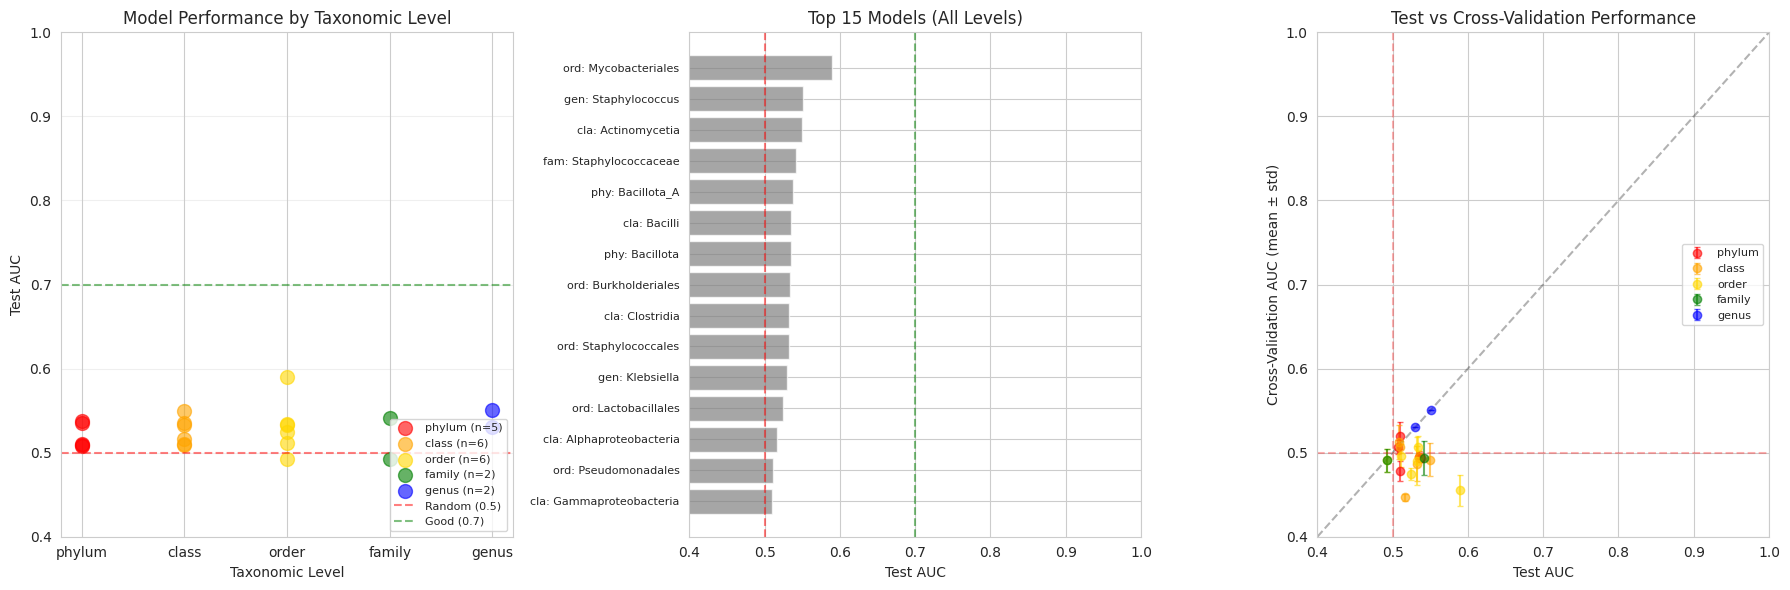

Saved: model_performance_overview.pdf


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel A: Test AUC distribution by taxonomic level
ax = axes[0]
tax_level_colors = {'phylum': 'red', 'class': 'orange', 'order': 'gold', 'family': 'green', 'genus': 'blue'}
for tax_level in TAXONOMIC_LEVELS:
    df_level = df_results[df_results['tax_level'] == tax_level]
    if len(df_level) > 0:
        ax.scatter([tax_level]*len(df_level), df_level['test_auc'], 
                   alpha=0.6, s=100, color=tax_level_colors.get(tax_level, 'gray'),
                   label=f"{tax_level} (n={len(df_level)})")

ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random (0.5)')
ax.axhline(y=0.7, color='green', linestyle='--', alpha=0.5, label='Good (0.7)')
ax.set_ylabel('Test AUC')
ax.set_xlabel('Taxonomic Level')
ax.set_title('Model Performance by Taxonomic Level')
ax.legend(loc='lower right', fontsize=8)
ax.set_ylim([0.4, 1.0])
ax.grid(axis='y', alpha=0.3)

# Panel B: Top 15 models overall
ax = axes[1]
df_plot = df_results.nlargest(15, 'test_auc')
colors = ['green' if auc > 0.70 else 'orange' if auc > 0.60 else 'gray' 
          for auc in df_plot['test_auc']]
y_pos = range(len(df_plot))
ax.barh(y_pos, df_plot['test_auc'], color=colors, alpha=0.7)
ax.set_yticks(y_pos)
# Combine tax level and taxon name for labels
labels = [f"{row['tax_level'][:3]}: {row['taxon'].split('__')[-1][:30]}" 
          for _, row in df_plot.iterrows()]
ax.set_yticklabels(labels, fontsize=8)
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5)
ax.axvline(x=0.7, color='green', linestyle='--', alpha=0.5)
ax.set_xlabel('Test AUC')
ax.set_title('Top 15 Models (All Levels)')
ax.set_xlim([0.4, 1.0])
ax.invert_yaxis()

# Panel C: Test vs CV AUC
ax = axes[2]
for tax_level in TAXONOMIC_LEVELS:
    df_level = df_results[df_results['tax_level'] == tax_level]
    if len(df_level) > 0:
        ax.errorbar(df_level['test_auc'], df_level['cv_auc_mean'], 
                    yerr=df_level['cv_auc_std'],
                    fmt='o', alpha=0.6, capsize=2,
                    color=tax_level_colors.get(tax_level, 'gray'),
                    label=tax_level)

ax.plot([0.4, 1.0], [0.4, 1.0], 'k--', alpha=0.3)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.3)
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.3)
ax.set_xlabel('Test AUC')
ax.set_ylabel('Cross-Validation AUC (mean ± std)')
ax.set_title('Test vs Cross-Validation Performance')
ax.legend(fontsize=8)
ax.set_xlim([0.4, 1.0])
ax.set_ylim([0.4, 1.0])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_performance_overview.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: model_performance_overview.pdf")

---
## 4. Feature Importance and Interpretation

Identify which environmental gradients drive taxonomic predictions.

### 4.1. Extract Feature Importance for Top Models

In [13]:
# Get top 5 performing models (across all taxonomic levels)
top_models = df_results.nlargest(5, 'test_auc')

# Store importance results
importance_results = []

for _, row in top_models.iterrows():
    tax_level = row['tax_level']
    taxon = row['taxon']
    model_key = f"{tax_level}__{taxon}"
    
    if model_key not in trained_models:
        print(f"Warning: Model not found for {model_key}")
        continue
    
    model = trained_models[model_key]
    
    # Get feature importance
    importance = model.get_feature_importance()
    feature_names = pca_feature_names
    
    # Create dataframe
    df_imp = pd.DataFrame({
        'feature': feature_names,
        'importance': importance,
        'tax_level': tax_level,
        'taxon': taxon,
        'test_auc': row['test_auc']
    })
    df_imp = df_imp.sort_values('importance', ascending=False)
    
    importance_results.append(df_imp)
    
    print(f"{tax_level}: {taxon.split('__')[-1][:40]} (AUC: {row['test_auc']:.3f})")
    print("Top 10 features:")
    print(df_imp.head(10)[['feature', 'importance']].to_string(index=False))
    print()

# Combine all importance results
if len(importance_results) > 0:
    df_importance_all = pd.concat(importance_results, ignore_index=True)
    df_importance_all.to_csv(OUTPUT_DIR / 'feature_importance_top_models.csv', index=False)
    print("Saved: feature_importance_top_models.csv")
else:
    print("No importance results to save.")

order: Mycobacteriales (AUC: 0.590)
Top 10 features:
        feature  importance
embeddings_PC17    8.820432
 topography_PC1    8.058649
embeddings_PC16    6.579575
embeddings_PC23    4.892267
 vegetation_PC6    4.743692
embeddings_PC28    4.666807
    climate_PC4    4.280599
embeddings_PC24    3.903651
 vegetation_PC7    3.831083
embeddings_PC19    3.739234

genus: Staphylococcus (AUC: 0.551)
Top 10 features:
        feature  importance
embeddings_PC27   28.675725
embeddings_PC17   20.339130
embeddings_PC30   17.470125
 vegetation_PC5   15.478672
       soil_PC3   13.445029
embeddings_PC21    4.591319
    climate_PC1    0.000000
embeddings_PC18    0.000000
 embeddings_PC9    0.000000
embeddings_PC10    0.000000

class: Actinomycetia (AUC: 0.550)
Top 10 features:
        feature  importance
embeddings_PC16   12.908561
embeddings_PC17   12.653339
 vegetation_PC8   10.407257
embeddings_PC21    9.445920
embeddings_PC27    8.889178
       soil_PC3    8.383660
embeddings_PC11    6.918028
 e

### 4.2. Visualize Feature Importance

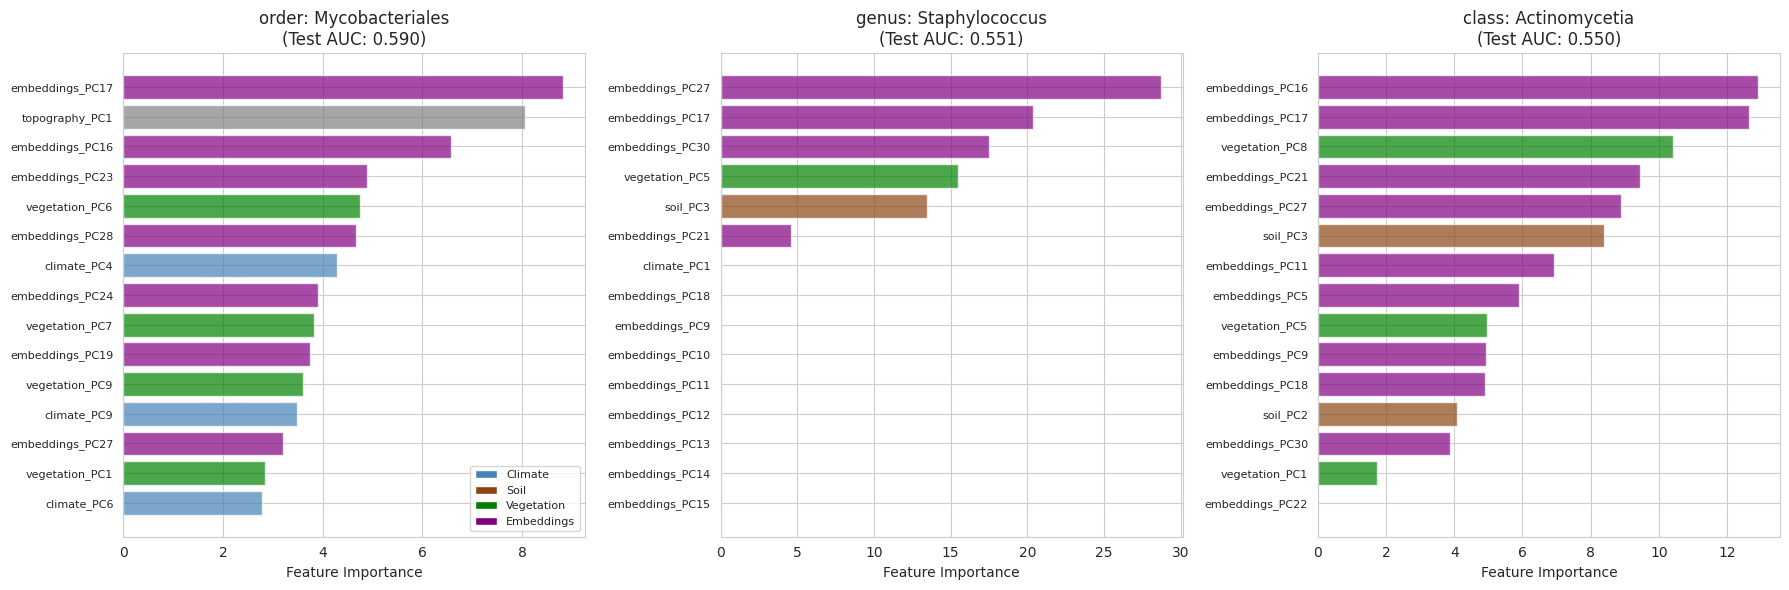

Saved: feature_importance_top3_models.pdf


In [14]:
# Plot for top 3 models
if len(importance_results) >= 3:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for i in range(min(3, len(importance_results))):
        ax = axes[i]
        df_imp = importance_results[i].head(15)
        
        # Color by domain
        colors = []
        for feat in df_imp['feature']:
            if 'climate' in feat.lower():
                colors.append('steelblue')
            elif 'soil' in feat.lower():
                colors.append('saddlebrown')
            elif 'vegetation' in feat.lower():
                colors.append('green')
            elif 'embeddings' in feat.lower():
                colors.append('purple')
            else:
                colors.append('gray')
        
        ax.barh(range(len(df_imp)), df_imp['importance'], color=colors, alpha=0.7)
        ax.set_yticks(range(len(df_imp)))
        ax.set_yticklabels(df_imp['feature'], fontsize=8)
        ax.set_xlabel('Feature Importance')
        
        # Add taxonomic level to title
        tax_level = df_imp['tax_level'].iloc[0]
        taxon_name = df_imp['taxon'].iloc[0].split('__')[-1]
        test_auc = df_imp['test_auc'].iloc[0]
        ax.set_title(f"{tax_level}: {taxon_name}\n(Test AUC: {test_auc:.3f})")
        ax.invert_yaxis()
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='steelblue', label='Climate'),
        Patch(facecolor='saddlebrown', label='Soil'),
        Patch(facecolor='green', label='Vegetation'),
        Patch(facecolor='purple', label='Embeddings')
    ]
    axes[0].legend(handles=legend_elements, loc='lower right', fontsize=8)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'feature_importance_top3_models.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Saved: feature_importance_top3_models.pdf")
else:
    print(f"Not enough models for visualization (only {len(importance_results)} available)")

### 4.3. Domain-Level Importance Summary

Aggregate importance by environmental domain.

In [15]:
# Map features to domains
def map_feature_to_domain(feature_name):
    if 'climate' in feature_name.lower():
        return 'climate'
    elif 'soil' in feature_name.lower():
        return 'soil'
    elif 'vegetation' in feature_name.lower():
        return 'vegetation'
    elif 'embeddings' in feature_name.lower():
        return 'embeddings'
    elif 'topography' in feature_name.lower():
        return 'topography'
    else:
        return 'other'

if len(importance_results) > 0:
    df_importance_all['domain'] = df_importance_all['feature'].apply(map_feature_to_domain)
    
    # Create a unique key for each model
    df_importance_all['model_key'] = df_importance_all['tax_level'] + '__' + df_importance_all['taxon']
    
    # Aggregate by domain and model
    domain_importance = df_importance_all.groupby(['model_key', 'domain'])['importance'].sum().reset_index()
    domain_importance = domain_importance.pivot(index='model_key', columns='domain', values='importance').fillna(0)
    
    # Normalize to percentages
    domain_importance_pct = domain_importance.div(domain_importance.sum(axis=1), axis=0) * 100
    
    print("Domain-level importance (% of total importance) for top models:\n")
    print(domain_importance_pct.to_string())
    
    # Save
    domain_importance_pct.to_csv(OUTPUT_DIR / 'domain_importance_summary.csv')
    print("\nSaved: domain_importance_summary.csv")
else:
    print("No importance results to analyze.")

Domain-level importance (% of total importance) for top models:

domain                          climate  embeddings       soil  topography  vegetation
model_key                                                                             
class__c__Actinomycetia        0.000000   70.444235  12.451968    0.000000   17.103796
family__f__Staphylococcaceae  15.494267   57.151848   3.744335    3.507931   20.101619
genus__g__Staphylococcus       0.000000   71.076299  13.445029    0.000000   15.478672
order__o__Mycobacteriales     15.993080   52.362079   4.019017    8.058649   19.567174
phylum__p__Bacillota_A        18.934421   59.645364   3.691401    1.634121   16.094693

Saved: domain_importance_summary.csv


### 4.4. Visualize Domain Importance

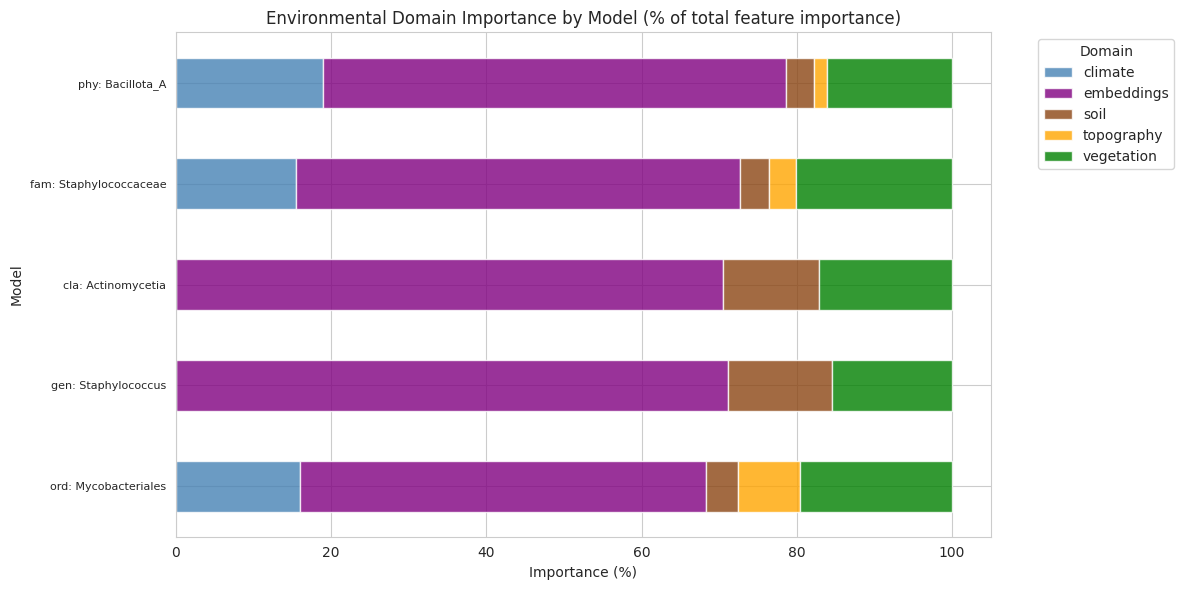

Saved: domain_importance_by_taxon.pdf


In [16]:
# Stacked bar chart
if len(importance_results) > 0 and 'domain_importance_pct' in locals():
    fig, ax = plt.subplots(figsize=(12, 6))
    
    domain_colors = {
        'climate': 'steelblue',
        'soil': 'saddlebrown',
        'vegetation': 'green',
        'embeddings': 'purple',
        'topography': 'orange'
    }
    
    # Sort models by test AUC
    model_auc_map = df_results.set_index(df_results['tax_level'] + '__' + df_results['taxon'])['test_auc'].to_dict()
    sorted_models = sorted(domain_importance_pct.index, key=lambda x: model_auc_map.get(x, 0), reverse=True)
    domain_importance_pct_sorted = domain_importance_pct.loc[sorted_models]
    
    # Plot stacked bars
    domain_importance_pct_sorted.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        color=[domain_colors.get(col, 'gray') for col in domain_importance_pct_sorted.columns],
        alpha=0.8
    )
    
    ax.set_xlabel('Importance (%)')
    ax.set_ylabel('Model')
    ax.set_title('Environmental Domain Importance by Model (% of total feature importance)')
    # Simplify y-axis labels: show tax level + short name
    labels = []
    for model_key in domain_importance_pct_sorted.index:
        parts = model_key.split('__')
        if len(parts) >= 2:
            tax_level = parts[0][:3]
            taxon_name = parts[-1].split('__')[-1][:25]
            labels.append(f"{tax_level}: {taxon_name}")
        else:
            labels.append(model_key[:30])
    ax.set_yticklabels(labels, fontsize=8)
    ax.legend(title='Domain', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'domain_importance_by_taxon.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Saved: domain_importance_by_taxon.pdf")
else:
    print("No domain importance data to visualize.")

---
## 5. Hierarchical Divergence Analysis

Test whether child taxa within successful parent models show divergent environmental associations. If children respond differently to environment, this suggests ecological differentiation within the parent taxon.

**Approach:**
1. Select phyla with good model performance (AUC > 0.65)
2. Build models for child classes within each phylum
3. Compute correlation between child model predictions (low r = divergent niches)
4. Identify variables that discriminate between divergent children
5. Report hierarchical structure of environmental associations

### 5.5. Interpretation: What Does Divergence Mean?

**Convergent children** (high correlation between predictions):
- Child taxa within the phylum share similar environmental associations
- Phylum-level environmental signal is strong and consistent
- Environmental niches overlap among children

**Divergent children** (low correlation between predictions):
- Child taxa have distinct environmental niches
- Environmental factors that predict one child class differ from those predicting siblings
- Suggests ecological differentiation within the phylum
- Discriminating variables reveal **which** environmental axes drive the split

**Next steps for divergent phyla:**
- Recurse to order level (grandchildren) to see if divergence continues
- Test if divergence aligns with phylogenetic distance
- Examine whether discriminating variables represent known ecological trade-offs

In [18]:
# Select phyla with strong environmental signal for divergence analysis
divergence_auc_threshold = 0.65
phylum_results = df_results[df_results['tax_level'] == 'phylum']
candidate_phyla = phylum_results[phylum_results['test_auc'] > divergence_auc_threshold]['taxon'].tolist()

print(f"Candidate phyla for divergence analysis (AUC > {divergence_auc_threshold}):")
print(f"  {len(candidate_phyla)} phyla\n")

for phylum in candidate_phyla:
    auc = phylum_results[phylum_results['taxon'] == phylum]['test_auc'].values[0]
    print(f"  {phylum.split('__')[-1]}: AUC = {auc:.3f}")

if len(candidate_phyla) == 0:
    print("\nNo phyla meet AUC threshold. Lowering threshold to 0.55...")
    divergence_auc_threshold = 0.55
    candidate_phyla = phylum_results[phylum_results['test_auc'] > divergence_auc_threshold]['taxon'].tolist()
    print(f"Candidate phyla: {len(candidate_phyla)}")
    
    if len(candidate_phyla) == 0:
        print("Still no candidates. Skipping divergence analysis.")
        # Set flag to skip subsequent divergence cells
        skip_divergence = True
    else:
        skip_divergence = False
        for phylum in candidate_phyla:
            auc = phylum_results[phylum_results['taxon'] == phylum]['test_auc'].values[0]
            print(f"  {phylum.split('__')[-1]}: AUC = {auc:.3f}")
else:
    skip_divergence = False

Candidate phyla for divergence analysis (AUC > 0.65):
  0 phyla


No phyla meet AUC threshold. Lowering threshold to 0.55...
Candidate phyla: 0
Still no candidates. Skipping divergence analysis.


### 5.4. Visualize Hierarchical Divergence

In [ ]:
# Store divergence analysis results
divergence_results = []
child_models = {}

if not skip_divergence:
    for phylum in candidate_phyla[:3]:  # Analyze top 3 for demonstration
        print(f"\n{'='*60}")
        print(f"Analyzing: {phylum.split('__')[-1]}")
        print(f"{'='*60}")
        
        # Get genomes belonging to this phylum
        phylum_mask = df_model_pca['phylum'] == phylum
        df_phylum = df_model_pca[phylum_mask].copy()
        
        print(f"Genomes in phylum: {len(df_phylum):,}")
        
        # Identify major classes within this phylum
        if 'class' not in df_phylum.columns:
            print("  → Skipped (no class column)")
            continue
            
        class_counts = df_phylum['class'].value_counts()
        min_class_count = int(len(df_phylum) * DIV_MIN_PREVALENCE)
        major_classes = class_counts[class_counts >= min_class_count].index.tolist()
        
        print(f"Major classes (≥{DIV_MIN_PREVALENCE:.0%} within phylum): {len(major_classes)}")
        
        if len(major_classes) < 2:
            print("  → Skipped (need ≥2 classes for divergence analysis)")
            continue
        
        # Build models for each child class
        child_predictions = {}
        child_performance = {}
        
        for child_class in major_classes[:5]:  # Limit to 5 classes for speed
            # Create binary target: this class vs other classes in phylum
            y_child = (df_phylum['class'] == child_class).astype(int)
            X_child = df_phylum[pca_feature_names].fillna(0)
            
            prevalence = y_child.mean()
            if prevalence < 0.1 or prevalence > 0.9:
                continue
            
            # Train/test split
            try:
                X_train, X_test, y_train, y_test = train_test_split(
                    X_child, y_child, test_size=0.2, stratify=y_child, random_state=RANDOM_STATE
                )
            except ValueError as e:
                print(f"  Skipping {child_class.split('__')[-1]}: {e}")
                continue
            
            # Train child model
            child_model = CatBoostClassifier(
                iterations=500,  # Fewer iterations for speed
                learning_rate=CATBOOST_PARAMS['learning_rate'],
                depth=CATBOOST_PARAMS['depth'],
                l2_leaf_reg=CATBOOST_PARAMS['l2_leaf_reg'],
                random_state=RANDOM_STATE,
                verbose=False
            )
            
            child_model.fit(X_train, y_train, eval_set=(X_test, y_test), verbose=False)
            
            # Get predictions on full phylum dataset
            y_pred_proba = child_model.predict_proba(X_child)[:, 1]
            child_predictions[child_class] = y_pred_proba
            
            # Evaluate
            test_auc = roc_auc_score(y_test, child_model.predict_proba(X_test)[:, 1])
            child_performance[child_class] = {
                'prevalence': prevalence,
                'test_auc': test_auc,
                'model': child_model
            }
            
            print(f"  {child_class.split('__')[-1]}: prevalence={prevalence:.1%}, AUC={test_auc:.3f}")
        
        if len(child_predictions) < 2:
            print("  → Skipped (need ≥2 successful child models)")
            continue
        
        # Store child models
        child_models[phylum] = child_performance
        
        # Compute pairwise correlations between child predictions
        df_child_pred = pd.DataFrame(child_predictions)
        corr_matrix = df_child_pred.corr(method='spearman')
        
        # Get upper triangle (exclude diagonal)
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
        correlations = corr_matrix.where(mask).stack()
        
        mean_corr = correlations.mean()
        min_corr = correlations.min()
        
        print(f"\n  Child prediction correlations:")
        print(f"    Mean: {mean_corr:.3f}")
        print(f"    Min: {min_corr:.3f}")
        
        # Interpret divergence
        if mean_corr < DIV_CORR_THRESHOLD:
            divergence_status = "DIVERGENT"
            print(f"    → {divergence_status} (mean r < {DIV_CORR_THRESHOLD})")
        else:
            divergence_status = "CONVERGENT"
            print(f"    → {divergence_status} (mean r ≥ {DIV_CORR_THRESHOLD})")
        
        # Store results
        divergence_results.append({
            'phylum': phylum,
            'n_genomes': len(df_phylum),
            'n_classes': len(major_classes),
            'n_classes_modeled': len(child_predictions),
            'mean_correlation': mean_corr,
            'min_correlation': min_corr,
            'divergence_status': divergence_status,
            'child_classes': list(child_predictions.keys())
        })

    # Create results dataframe
    if len(divergence_results) > 0:
        df_divergence = pd.DataFrame(divergence_results)
        print(f"\n\nDivergence Analysis Summary:")
        print(df_divergence[['phylum', 'n_classes_modeled', 'mean_correlation', 'divergence_status']].to_string(index=False))
    else:
        print("\nNo phyla met criteria for divergence analysis.")
        skip_divergence = True  # Skip visualization cells
else:
    print("Skipping divergence analysis (no candidate phyla).")

### 5.3. Identify Discriminating Variables for Divergent Children

In [ ]:
# For divergent phyla, identify which variables discriminate between child taxa
discriminating_vars = []

if not skip_divergence and len(divergence_results) > 0:
    for result in divergence_results:
        if result['divergence_status'] == 'DIVERGENT':
            phylum = result['phylum']
            child_classes = result['child_classes']
            
            print(f"\n{'='*60}")
            print(f"Discriminating variables for: {phylum.split('__')[-1]}")
            print(f"{'='*60}")
            
            # Get feature importance from each child model
            child_importances = {}
            for child_class in child_classes:
                if phylum in child_models and child_class in child_models[phylum]:
                    model = child_models[phylum][child_class]['model']
                    importance = model.get_feature_importance()
                    child_importances[child_class] = importance
            
            if len(child_importances) < 2:
                print("  → Skipped (insufficient child models)")
                continue
            
            # Create importance matrix: features × classes
            df_imp_matrix = pd.DataFrame(child_importances, index=pca_feature_names)
            
            # Compute variance in importance across children (high variance = discriminating)
            importance_variance = df_imp_matrix.var(axis=1)
            top_discriminating = importance_variance.nlargest(DIV_TOP_VARS)
            
            print(f"\nTop {DIV_TOP_VARS} discriminating features:")
            for i, (feature, variance) in enumerate(top_discriminating.items(), 1):
                # Show importance for each child
                child_imps = df_imp_matrix.loc[feature]
                imp_str = ", ".join([f"{cls.split('__')[-1][:20]}: {imp:.1f}" 
                                     for cls, imp in child_imps.items()])
                print(f"  {i}. {feature}")
                print(f"     Variance: {variance:.1f}, Child importances: [{imp_str}]")
                
                discriminating_vars.append({
                    'phylum': phylum,
                    'feature': feature,
                    'variance': variance,
                    'mean_importance': df_imp_matrix.loc[feature].mean()
                })
    
    # Save discriminating variables
    if len(discriminating_vars) > 0:
        df_discriminating = pd.DataFrame(discriminating_vars)
        df_discriminating.to_csv(OUTPUT_DIR / 'hierarchical_divergence_discriminating_vars.csv', index=False)
        print(f"\n\nSaved: hierarchical_divergence_discriminating_vars.csv")
    else:
        print("\nNo discriminating variables found.")
else:
    print("Skipping discriminating variable analysis (no divergent phyla).")

### 5.2. Build Child Models for Each Candidate Phylum

In [ ]:
if not skip_divergence and len(divergence_results) > 0:
    # Plot divergence analysis results
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Panel A: Correlation structure for each phylum
    ax = axes[0]
    x_pos = []
    y_vals = []
    colors_list = []
    labels_list = []
    
    for i, result in enumerate(divergence_results):
        phylum_name = result['phylum'].split('__')[-1][:15]
        mean_corr = result['mean_correlation']
        
        x_pos.append(i)
        y_vals.append(mean_corr)
        
        if result['divergence_status'] == 'DIVERGENT':
            colors_list.append('red')
        else:
            colors_list.append('blue')
        
        labels_list.append(phylum_name)
    
    ax.bar(x_pos, y_vals, color=colors_list, alpha=0.7)
    ax.axhline(y=DIV_CORR_THRESHOLD, color='black', linestyle='--', 
               label=f'Divergence threshold ({DIV_CORR_THRESHOLD})')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels_list, rotation=45, ha='right')
    ax.set_ylabel('Mean Correlation Between Child Models')
    ax.set_title('Hierarchical Divergence Analysis\n(Low correlation = divergent environmental niches)')
    ax.legend()
    ax.set_ylim([0, 1])
    
    # Panel B: Number of classes modeled per phylum
    ax = axes[1]
    ax.bar(x_pos, [r['n_classes_modeled'] for r in divergence_results], 
           color='steelblue', alpha=0.7)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels_list, rotation=45, ha='right')
    ax.set_ylabel('Number of Child Classes Modeled')
    ax.set_title('Taxonomic Diversity\n(Classes within each phylum)')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'hierarchical_divergence_analysis.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Saved: hierarchical_divergence_analysis.pdf")
    
    # Save divergence results
    df_divergence.to_csv(OUTPUT_DIR / 'hierarchical_divergence_results.csv', index=False)
    print("Saved: hierarchical_divergence_results.csv")
else:
    print("No divergence results to visualize.")

### 5.1. Select Phyla for Divergence Analysis

---
## Summary and Key Findings

In [ ]:
print("=" * 80)
print("PHASE 2 SUMMARY: HIERARCHICAL ENVIRONMENTAL-TAXONOMIC MODELING")
print("=" * 80)

print("\n1. DIMENSIONALITY REDUCTION")
print(f"   - Reduced {len(all_env_cols)} environmental variables to {len(pca_feature_names)} PCA features")
print(f"   - Target variance explained: {target_variance:.0%}")
print("   - Domain-specific PCA:")
for domain, df_comp in pca_components.items():
    n_orig = len(domain_vars[domain])
    n_pcs = df_comp.shape[1]
    print(f"     • {domain}: {n_orig} vars → {n_pcs} PCs")

print("\n2. MODEL PERFORMANCE")
print(f"   - Models trained: {len(df_results)}")
print(f"   - Mean Test AUC: {df_results['test_auc'].mean():.3f}")
print(f"   - Median Test AUC: {df_results['test_auc'].median():.3f}")
print(f"   - Best performing taxon: {df_results.loc[df_results['test_auc'].idxmax(), 'taxon'].split('__')[-1]} (AUC: {df_results['test_auc'].max():.3f})")
print(f"   - Models with AUC > 0.70: {(df_results['test_auc'] > 0.70).sum()} / {len(df_results)}")
print(f"   - Models with AUC > 0.60: {(df_results['test_auc'] > 0.60).sum()} / {len(df_results)}")

if len(df_results) > 0:
    print("\n3. KEY INSIGHTS")
    
    # Compare to Phase 1 univariate results
    phase1_auc = 0.512  # From summary
    improvement = df_results['test_auc'].mean() - phase1_auc
    
    if improvement > 0.05:
        print(f"   - Multivariate models show substantial improvement over univariate (Δ AUC: +{improvement:.3f})")
    elif improvement > 0:
        print(f"   - Modest improvement over univariate approach (Δ AUC: +{improvement:.3f})")
    else:
        print(f"   - Limited improvement over univariate approach (Δ AUC: {improvement:.3f})")
    
    # Domain importance insights
    mean_domain_imp = domain_importance_pct.mean(axis=0).sort_values(ascending=False)
    print(f"   - Most important environmental domain: {mean_domain_imp.index[0]} ({mean_domain_imp.iloc[0]:.1f}% avg importance)")
    print(f"   - Environmental gradients (PCA features) are more predictive than raw variables")
    
    # Taxa-specific insights
    best_taxon = df_results.loc[df_results['test_auc'].idxmax()]
    print(f"   - {best_taxon['taxon'].split('__')[-1]} shows strongest environmental signal (prevalence: {best_taxon['prevalence']:.1%})")

print("\n4. OUTPUTS GENERATED")
outputs = [
    'pca_variance_explained_by_domain.pdf',
    'catboost_model_performance.csv',
    'model_performance_overview.pdf',
    'feature_importance_top_models.csv',
    'feature_importance_top3_models.pdf',
    'domain_importance_summary.csv',
    'domain_importance_by_taxon.pdf'
]
for output in outputs:
    print(f"   - {output}")

print("\n5. NEXT STEPS")
print("   - Extend modeling to class and order levels")
print("   - Implement hierarchical divergence analysis (Phase 5c)")
print("   - Test conditional variable importance (confound analysis)")
print("   - Generate partial dependence plots for top features")
print("   - Validate models on spatial holdout regions")

print("\n" + "=" * 80)